# **Modelo 1**

Dataset: **dataset_caracteristicas_train_V1_ALL.csv**

## Puntos desarrolados en este notebook:

- **Sección 1**: reproducimos el mismo pipeline de datos utilizado en el modelo EDA (undersampling + split train/test). Esto nos permite trabajar con los mismos 4000 audios de train que analizamos en el modelo EDA;

- **Sección 2**: optimizamos los hiperparámetros de los 3 modelos (Random Forest, XGBoost, Red Neuronal MLP) mediante `RandomizedSearchCV` y los entrenamos con los parámetros óptimos encontrados;

- **Sección 3**: aplicamos validación cruzada estratificada (5-fold) para obtener métricas robustas;

- **Sección 4**: análisis de overfitting (comparamos métricas de train versus validación. La validación es el fold de reserva del 5-Fold StratifiedKFold, que rota dentro de los 4,000 registros de train). El hecho de que sea estratificado garantiza que cada fold (cada fold tiene 800 registros) mantiene la misma proporción de clases y como el dataset está balanceado, cada fold tiene 400 audios bonafide y 400 audios spoof;

- **Sección 5**: learning curves (calculamos la learning curve de cada modelo para analizar cómo evoluciona el rendimiento en función del tamaño del conjunto de entrenamiento). Aplicamos el criterio ΔVal < 0.005 entre puntos consecutivos para detectar el primer punto de desaceleración significativa: el tamaño N a partir del cual la ganancia marginal de añadir más datos baja por debajo del 0.5%. Este punto no implica que el modelo haya alcanzado su techo - todos los modelos siguen mejorando más allá de ese N - sino que marca el inicio de los rendimientos decrecientes dentro del rango de datos disponible;

- **Sección 6**: evaluación final en el conjunto de test del modelo elegido (el mejor modelo optimizado);

- **Sección 7**: resumen, ranking y conclusiones.


### ***Bloque 1: configuración global***

In [17]:
# Bloque 1: cargamos las librerias + configuración global

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, learning_curve, RandomizedSearchCV
)
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    print('XGBoost no instalado. Instalar con: pip install xgboost')
    XGB_AVAILABLE = False

# Configuración estética
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.titleweight']   = 'bold'
plt.rcParams['axes.titlesize']     = 12

# Parámetros globales (identicos al EDA para garantizar la reproducibilidad)
RANDOM_STATE  = 42
N_PER_CLASS   = 2500   # registros por clase tras undersampling
TEST_SIZE     = 0.20   # 80% train / 20% test - sellado hasta evaluación final
N_FOLDS       = 5      # folds para validación cruzada
DATA_PATH     = '../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv'

print('Librerías cargadas correctamente')
print(f'RANDOM_STATE={RANDOM_STATE} | N_PER_CLASS={N_PER_CLASS} | N_FOLDS={N_FOLDS}')
print(f'XGBoost disponible: {XGB_AVAILABLE}')

Librerías cargadas correctamente
RANDOM_STATE=42 | N_PER_CLASS=2500 | N_FOLDS=5
XGBoost disponible: True


## **SECCIÓN 1: REPRODUCCIÓN DEL PIPELINE DE DATOS DEL EDA**

Reproducimos el mismo proceso del `Modelo_EDA_Daniele.ipynb` con la misma semilla (`random_state=42`), asegurando que trabajamos con los ***mismos 4.000 registros de train*** que analizamos en el modelo del EDA.

**PROBLEMA**: Por qué reproducimos el pipeline en lugar de guardar y cargar un nuevo CSV? 

**DECISIÓN TOMADA**: reproducir el pipeline con la misma semilla nos permite asegurar la **consistencia** (si el dataset original cambia, el pipeline se actualiza automáticamente) y previene el **Data Leakage** (como hicimos en el modelo del EDA, el conjunto de test sigue no fue visto durante el analisis exploratorio de los datos).

Las features seleccionadas son todas las columnas numéricas excepto `file_name`, `attack_id` y `label`.

### ***Bloque 2: carga y reproducción del pipeline de datos***

In [18]:
# Bloque 2: carga y reproducción del pipeline de datos

# Cargamos el dataset completo
df_full = pd.read_csv(DATA_PATH)
print(f'El dataset completo tiene {df_full.shape[0]:,} filas y {df_full.shape[1]} columnas')

# Undersampling estratificado por attack_id
df_bonafide = df_full[df_full['label'] == 'bonafide'].copy()
df_spoof    = df_full[df_full['label'] == 'spoof'].copy()

# Undersample bonafide
n_bonafide    = min(len(df_bonafide), N_PER_CLASS)
df_bon_sample = df_bonafide.sample(n=n_bonafide, random_state=RANDOM_STATE)

# Undersample spoof proporcional por attack_id
attack_counts = df_spoof['attack_id'].value_counts()
proportions   = attack_counts / attack_counts.sum()
n_spoof_total = N_PER_CLASS
n_per_attack  = (proportions * n_spoof_total).astype(int)
deficit       = n_spoof_total - n_per_attack.sum()
for atk in n_per_attack.nlargest(abs(deficit)).index:
    n_per_attack[atk] += int(np.sign(deficit))

spoof_samples = []
for attack_id, n in n_per_attack.items():
    subset = df_spoof[df_spoof['attack_id'] == attack_id]
    spoof_samples.append(subset.sample(n=min(n, len(subset)), random_state=RANDOM_STATE))

df_spoof_sample = pd.concat(spoof_samples)
df_balanced = pd.concat([df_bon_sample, df_spoof_sample]).sample(
    frac=1, random_state=RANDOM_STATE
).reset_index(drop=True)

# Definimos las features y la variable target
FEATURE_COLS = [c for c in df_balanced.columns if c not in ['file_name', 'attack_id', 'label']]
TARGET_COL   = 'label'

X = df_balanced[FEATURE_COLS]
y = df_balanced[TARGET_COL]

# Separación train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Codificación de etiquetas: bonafide=0, spoof=1
le = LabelEncoder()
le.fit(['bonafide', 'spoof'])
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print('PIPELINE DE DATOS REPRODUCIDO')
print(f'Dataset balanceado : {df_balanced.shape[0]:,} filas')
print(f'Features           : {len(FEATURE_COLS)}')
print(f'Train              : {X_train.shape[0]:,} filas')
print(f'Test (SELLADO)     : {X_test.shape[0]:,} filas')
print()
print('Distribución de clases en el conjunto de TRAIN:')
print(y_train.value_counts().to_string())
print('\nDistribución de clases en el conjunto de TEST:')
print(y_test.value_counts().to_string())
print('\nEl conjunto de TEST se usará solo en la evaluación final')

El dataset completo tiene 25,380 filas y 37 columnas
PIPELINE DE DATOS REPRODUCIDO
Dataset balanceado : 5,000 filas
Features           : 34
Train              : 4,000 filas
Test (SELLADO)     : 1,000 filas

Distribución de clases en el conjunto de TRAIN:
label
spoof       2000
bonafide    2000

Distribución de clases en el conjunto de TEST:
label
bonafide    500
spoof       500

El conjunto de TEST se usará solo en la evaluación final


## **SECCIÓN 2: Optimización de Hiperparámetros y Definición de los 3 Modelos**

Antes de entrenar los modelos definitivos, buscamos los **hiperparámetros óptimos** para cada uno mediante `RandomizedSearchCV` con validación cruzada estratificada de 5 folds sobre los **4.000 datos de train**.

**DECISIÓN TOMADA**: en lugar de partir de hiperparámetros iniciales arbitrarios (baseline), optimizamos directamente los tres modelos desde el principio. Esto nos permite comparar los tres modelos ya en su mejor versión y elegir el ganador de forma más justa.

**Espacio de búsqueda por modelo:**

| Modelo | Hiperparámetros optimizados | Iteraciones |
|--------|----------------------------|-------------|
| **Random Forest** | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` | 30 |
| **XGBoost** | `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`, `min_child_weight` | 50 |
| **Red Neuronal (MLP)** | `hidden_layer_sizes`, `alpha`, `learning_rate_init`, `max_iter` | 20 |

El MLP incluye un `StandardScaler` dentro del pipeline porque las redes neuronales son sensibles a la escala de las features. Random Forest y XGBoost no son sensibles y no necesitan estandarización previa de las features.

### ***Bloque 3: optimización con RandomizedSearchCV y definición de los 3 modelos optimizados***

In [19]:
# Bloque 3: optimización de hiperparámetros (RandomizedSearchCV) y definición de los 3 modelos optimizados

cv_search = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# ─────────────────────────────────────────────────────────────
# 1. Random Forest – RandomizedSearchCV (30 iteraciones)
# ─────────────────────────────────────────────────────────────
rf_base = RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE)

param_dist_rf = {
    'n_estimators'     : randint(50, 500),
    'max_depth'        : [None, 5, 10, 15, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'max_features'     : ['sqrt', 'log2', None],
}

search_rf = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring='f1',
    cv=cv_search,
    refit=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

t0 = time.time()
search_rf.fit(X_train, y_train_enc)
print(f'Random Forest  – F1 óptimo (CV): {search_rf.best_score_:.4f}  ({time.time()-t0:.1f}s)')
print('  Hiperparámetros óptimos:')
for k, v in sorted(search_rf.best_params_.items()):
    print(f'    {k:<22}: {v}')

# ─────────────────────────────────────────────────────────────
# 2. XGBoost – RandomizedSearchCV (50 iteraciones)
# ─────────────────────────────────────────────────────────────
if XGB_AVAILABLE:
    xgb_base = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    param_dist_xgb = {
        'n_estimators'    : randint(100, 700),
        'max_depth'       : randint(3, 10),
        'learning_rate'   : uniform(0.01, 0.29),
        'subsample'       : uniform(0.60, 0.40),
        'colsample_bytree': uniform(0.50, 0.50),
        'reg_alpha'       : uniform(0.0, 1.0),
        'reg_lambda'      : uniform(0.5, 4.5),
        'min_child_weight': randint(1, 11),
    }

    search_xgb = RandomizedSearchCV(
        xgb_base,
        param_distributions=param_dist_xgb,
        n_iter=50,
        scoring='f1',
        cv=cv_search,
        refit=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0
    )

    t0 = time.time()
    search_xgb.fit(X_train, y_train_enc)
    print(f'\nXGBoost        – F1 óptimo (CV): {search_xgb.best_score_:.4f}  ({time.time()-t0:.1f}s)')
    print('  Hiperparámetros óptimos:')
    for k, v in sorted(search_xgb.best_params_.items()):
        print(f'    {k:<22}: {v}')
else:
    search_xgb = None
    print('\nXGBoost no disponible')

# ─────────────────────────────────────────────────────────────
# 3. Red Neuronal (MLP) – RandomizedSearchCV (20 iteraciones)
# ─────────────────────────────────────────────────────────────
mlp_base = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        solver='adam',
        activation='relu',
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=RANDOM_STATE
    ))
])

param_dist_mlp = {
    'mlp__hidden_layer_sizes': [(64, 32), (128, 64), (64, 64, 32), (128, 64, 32), (256, 128)],
    'mlp__alpha'              : uniform(0.0001, 0.09),
    'mlp__learning_rate_init' : uniform(0.001, 0.009),
    'mlp__max_iter'           : [300, 500],
}

search_mlp = RandomizedSearchCV(
    mlp_base,
    param_distributions=param_dist_mlp,
    n_iter=20,
    scoring='f1',
    cv=cv_search,
    refit=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

t0 = time.time()
search_mlp.fit(X_train, y_train_enc)
print(f'\nRed Neuronal   – F1 óptimo (CV): {search_mlp.best_score_:.4f}  ({time.time()-t0:.1f}s)')
print('  Hiperparámetros óptimos:')
for k, v in sorted(search_mlp.best_params_.items()):
    print(f'    {k:<22}: {v}')

# ─────────────────────────────────────────────────────────────
# 4. Definición de los modelos optimizados finales
# ─────────────────────────────────────────────────────────────
model_rf  = search_rf.best_estimator_
model_xgb = search_xgb.best_estimator_ if XGB_AVAILABLE else None
model_mlp = search_mlp.best_estimator_

# Diccionario de los modelos optimizados
models = {
    'Random Forest': model_rf,
    'XGBoost'      : model_xgb,
    'Red Neuronal' : model_mlp
}
if not XGB_AVAILABLE:
    models.pop('XGBoost')

print('\nModelos optimizados definidos correctamente.')

Random Forest  – F1 óptimo (CV): 0.9225  (165.2s)
  Hiperparámetros óptimos:
    max_depth             : None
    max_features          : log2
    min_samples_leaf      : 2
    min_samples_split     : 10
    n_estimators          : 395

XGBoost        – F1 óptimo (CV): 0.9484  (58.4s)
  Hiperparámetros óptimos:
    colsample_bytree      : 0.6379995910112717
    learning_rate         : 0.09591931665418388
    max_depth             : 7
    min_child_weight      : 1
    n_estimators          : 620
    reg_alpha             : 0.7722447692966574
    reg_lambda            : 1.3942205669037757
    subsample             : 0.602208846849441

Red Neuronal   – F1 óptimo (CV): 0.9597  (26.5s)
  Hiperparámetros óptimos:
    mlp__alpha            : 0.004299909689225389
    mlp__hidden_layer_sizes: (128, 64, 32)
    mlp__learning_rate_init: 0.004297256589643225
    mlp__max_iter         : 500

Modelos optimizados definidos correctamente.


## **SECCIÓN 3: Validación cruzada estratificada (5-Fold) de los modelos optimizados**

Evaluamos cada **modelo optimizado** con **StratifiedKFold (k=5)** sobre el conjunto de train y calculamos accuracy, precision, recall, F1-score, AUC-ROC (tanto en train como en validación).

Para evitar de entrenar los modelos y probarlos con los mismos datos, hicimos validación cruzada con 5 particiones (divididimos los datos de entrenamiento en 5 partes iguales) y usamos una parte para validar y las otras 4 partes para entrenar.

Por cada vuelta obtuvimos resultados de las metricas distintos, porque el trozo de validación es diferente. Calculamos la media y la desviación estandar media de los 5 resultados que obtuvimos por cada metrica y mostramos en una tabla los resultados de cada modelo.
La desviación estandar nos dice si las 5 vueltas dieron resultados de las metricas muy parecidos (entonces el modelo es estable) o no (el modelo es más variable).

Además calculamos el gap (o sea la diferencia entre el las metricas obtenidas para el conjunto de train y las metricas para la parte de validación). El gap nos dice que:

- si las metricas de train y de validación tienen valores bajos, entonces el modelo necesita más features (es demasiado simple);

- si las metricas de train tienen valores altos y las de validación bajos, entonces tenemos overfitting, porque el modelo memoriza los datos en el conjunto de train y no es capaz de generalizar bien cuando valida;
 
- si las métricas de train y de validación tienen valores altos y similares entre sí, entonces el modelo generaliza bien.

### ***Bloque 4: validación cruzada 5-fold***

In [20]:
#  Bloque 4: validación cruzada 5-fold

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc'
}

cv_results = {}

for name, model in models.items():
    print(f'{name}')
    t0 = time.time()

    # cross_validate devuelve métricas de train Y test (val) por fold
    cv_out = cross_validate(
        model, X_train, y_train_enc,
        cv=cv,
        scoring=SCORING,
        return_train_score=True,
        n_jobs=-1
    )
    elapsed = time.time() - t0
    cv_results[name] = cv_out

    # Métricas
    print(f'  Tiempo de entrenamiento: {elapsed:.1f}s')
    print(f'{'  Métrica':<20} {'Train (μ ± σ)':<22} {'Val (μ ± σ)':<22} {'GAP':>8}')
    print(f'  {'-'*80}')
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        tr_mean = cv_out[f'train_{metric}'].mean()
        tr_std  = cv_out[f'train_{metric}'].std()
        va_mean = cv_out[f'test_{metric}'].mean()
        va_std  = cv_out[f'test_{metric}'].std()
        gap     = tr_mean - va_mean
        flag    = 'OVERFITTING' if gap > 0.05 else 'NO OVERFITTING'
        print(f'  {metric.capitalize():<20} {tr_mean:.4f} ± {tr_std:.4f}      '
              f'{va_mean:.4f} ± {va_std:.4f}  {gap:+.4f} {flag}')
    print()

print('\nHemos completado la validación cruzada para todos los modelos')

Random Forest
  Tiempo de entrenamiento: 5.1s
  Métrica            Train (μ ± σ)          Val (μ ± σ)                 GAP
  --------------------------------------------------------------------------------
  Accuracy             0.9957 ± 0.0003      0.9240 ± 0.0053  +0.0717 OVERFITTING
  Precision            0.9989 ± 0.0003      0.9409 ± 0.0116  +0.0579 OVERFITTING
  Recall               0.9926 ± 0.0006      0.9050 ± 0.0081  +0.0876 OVERFITTING
  F1                   0.9957 ± 0.0003      0.9225 ± 0.0052  +0.0732 OVERFITTING
  Roc_auc              0.9999 ± 0.0000      0.9772 ± 0.0049  +0.0227 NO OVERFITTING

XGBoost
  Tiempo de entrenamiento: 3.3s
  Métrica            Train (μ ± σ)          Val (μ ± σ)                 GAP
  --------------------------------------------------------------------------------
  Accuracy             1.0000 ± 0.0000      0.9490 ± 0.0046  +0.0510 OVERFITTING
  Precision            1.0000 ± 0.0000      0.9601 ± 0.0078  +0.0399 NO OVERFITTING
  Recall              

### ***Bloque 5: representación visual de la validación cruzada 5-fold***

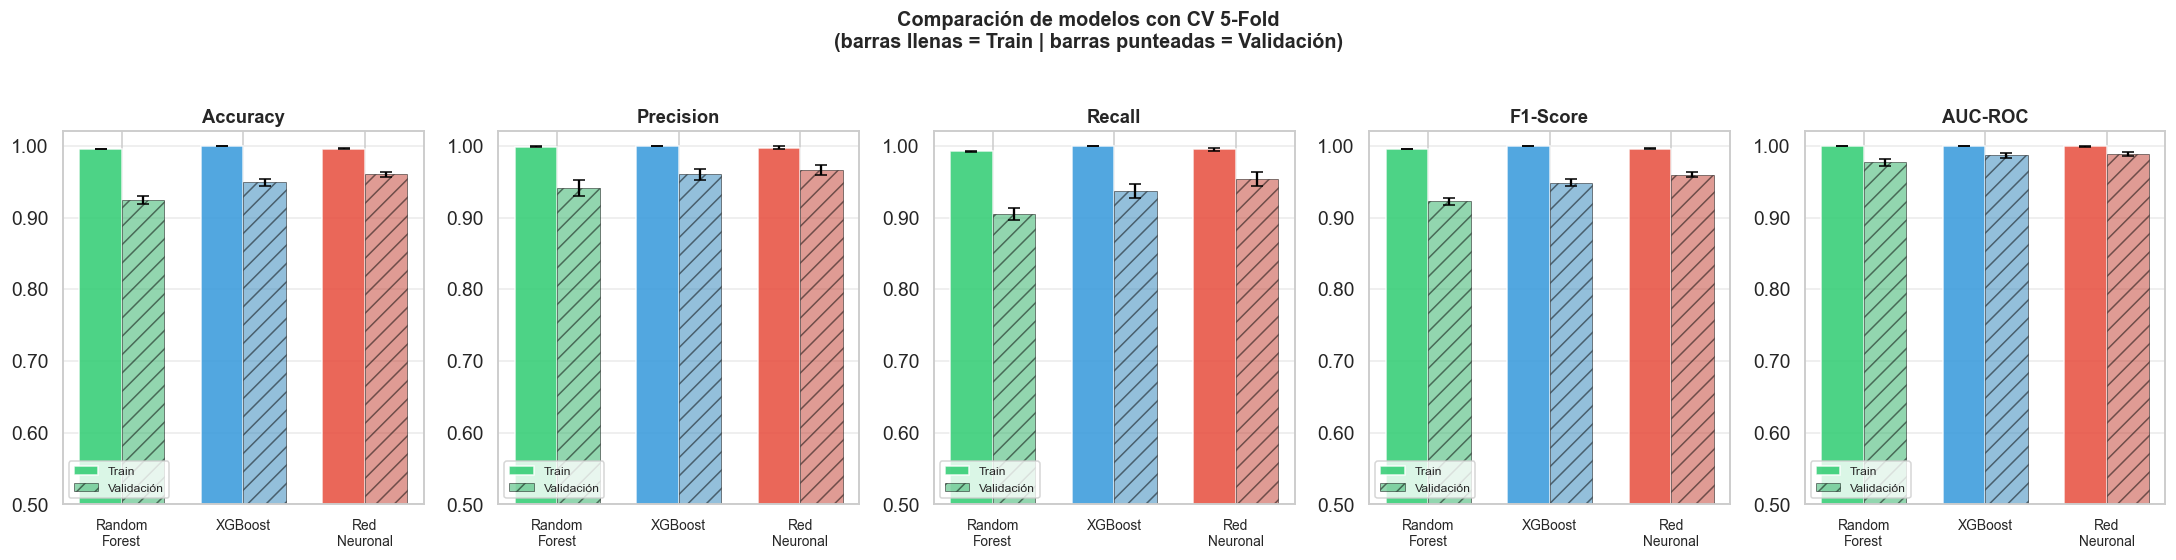

Hemos guardado el grafico en el archivo: modelo1_comparacion_cv.png


In [21]:
#  Bloque 5: representación grafica de CV 5-fold

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
model_names     = list(models.keys())
colors_train    = ['#2ecc71', '#3498db', '#e74c3c']
colors_val      = ['#27ae60', '#2980b9', '#c0392b']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))
fig.suptitle('Comparación de modelos con CV 5-Fold\n(barras llenas = Train | barras punteadas = Validación)',
             fontsize=13, fontweight='bold', y=1.02)

x = np.arange(len(model_names))
width  = 0.35

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    train_means = [cv_results[n][f'train_{metric}'].mean() for n in model_names]
    val_means   = [cv_results[n][f'test_{metric}'].mean()  for n in model_names]
    train_stds  = [cv_results[n][f'train_{metric}'].std()  for n in model_names]
    val_stds    = [cv_results[n][f'test_{metric}'].std()   for n in model_names]

    bars_tr = ax.bar(x - width/2, train_means, width, label='Train',
                     color=colors_train[:len(model_names)], alpha=0.85,
                     yerr=train_stds, capsize=4)
    bars_va = ax.bar(x + width/2, val_means, width, label='Validación',
                     color=colors_val[:len(model_names)], alpha=0.5,
                     hatch='//', edgecolor='black', linewidth=0.6,
                     yerr=val_stds, capsize=4)

    ax.set_title(label)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=9)
    ax.set_ylim(0.5, 1.02)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('modelo1_comparacion_cv.png', bbox_inches='tight', dpi=120)
plt.show()
print('Hemos guardado el grafico en el archivo: modelo1_comparacion_cv.png')

## **SECCIÓN 4: Análisis de Overfitting Validación Cruzada 5-fold**

Calculamos el **GAP Train - Validación** para cada métrica y modelo.  
Un Gap > 0.05 indica overfitting significativo que deberemos corregir.

El ***Random Forest** funciona bien en los datos que ya vió (Train F1 = 1.0000) pero pierde casi 8 puntos al enfrentarse a datos nuevos. El gap está por encima de 0.05, lo que indica que está memorizando demasiado. Es el modelo con peor generalización de los tres.

El ***XGBoost*** tiene una situación similar al Random Forest pero un poquito mejor. También memoriza muy bien, pero la caída en validación es menor. Necesita regularización para mejorar.

El modelo de ***Red Neuronal*** es el modelo que mejor generaliza. El gap está por debajo de 0.05, lo que indica que lo que aprendió en train funciona bien también en datos nuevos. Es el único que no llega a Train F1 = 1.0 (Train F1 ≈ 0.98), lo que representa una señal positiva: no memorizó, aprendió.

### ***Bloque 6: analisis de overfitting***

In [22]:
# Bloque 6: analisis de overfitting

overfitting_data = []
for name in model_names:
    row = {'Modelo': name}
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        tr = cv_results[name][f'train_{metric}'].mean()
        va = cv_results[name][f'test_{metric}'].mean()
        gap = tr - va
        row[f'{metric}_train'] = tr
        row[f'{metric}_val']   = va
        row[f'{metric}_gap']   = gap
    overfitting_data.append(row)

df_overfit = pd.DataFrame(overfitting_data).set_index('Modelo')

print(f'\n{"":<18} {"Accuracy":>18} {"Precision":>18} {"Recall":>18} {"F1":>18} {"AUC-ROC":>18}')
print(f'{"":<18} {"Train | Val | Gap":>18} {"Train | Val | Gap":>18} {"Train | Val | Gap":>18} {"Train | Val | Gap":>18} {"Train | Val | Gap":>18}')
print('-' * 108)
for name in model_names:
    row_str = f'{name:<18}'
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        tr  = df_overfit.loc[name, f'{metric}_train']
        va  = df_overfit.loc[name, f'{metric}_val']
        gap = df_overfit.loc[name, f'{metric}_gap']
        row_str += f' {tr:.3f}|{va:.3f}|{gap:+.3f}'
    print(row_str)

# Resumen del diagnostico
print()
print('DIAGNÓSTICO DE OVERFITTING')
for name in model_names:
    f1_gap = df_overfit.loc[name, 'f1_gap']
    if f1_gap > 0.10:
        diag = 'OVERFITTING SEVERO'
    elif f1_gap > 0.05:
        diag = 'OVERFITTING MODERADO'
    else:
        diag = 'AJUSTE ACEPTABLE'
    print(f'  {name:<18}: GAP F1 = {f1_gap:+.4f} : {diag}')


                             Accuracy          Precision             Recall                 F1            AUC-ROC
                    Train | Val | Gap  Train | Val | Gap  Train | Val | Gap  Train | Val | Gap  Train | Val | Gap
------------------------------------------------------------------------------------------------------------
Random Forest      0.996|0.924|+0.072 0.999|0.941|+0.058 0.993|0.905|+0.088 0.996|0.923|+0.073 1.000|0.977|+0.023
XGBoost            1.000|0.949|+0.051 1.000|0.960|+0.040 1.000|0.937|+0.063 1.000|0.948|+0.052 1.000|0.987|+0.013
Red Neuronal       0.996|0.960|+0.036 0.998|0.966|+0.031 0.995|0.954|+0.041 0.996|0.960|+0.037 0.999|0.989|+0.010

DIAGNÓSTICO DE OVERFITTING
  Random Forest     : GAP F1 = +0.0732 : OVERFITTING MODERADO
  XGBoost           : GAP F1 = +0.0516 : OVERFITTING MODERADO
  Red Neuronal      : GAP F1 = +0.0365 : AJUSTE ACEPTABLE


## **SECCIÓN 5: Learning Curves**

La **Learning Curve** muestra cómo evoluciona el rendimiento del modelo al aumentar la cantidad de datos de entrenamiento.  
La ejecutamos para cada modelo usando el conjunto de TRAIN completo (4.000 muestras).

### ***Mostramos un diagrama cartesiano para explicar como se lee la learning curve***:

```
Rendimiento
  ↑
  |   Train ────────────────────
  |   Val  ·  ·  ·  ·  ──────────
  |           ↑
  |           Punto de desaceleración
  └──────────────────────────────→ N muestras
```

- **Curva de train descendente:** es normal, el modelo generaliza mejor a medida que ve más datos y memoriza menos el ruido;

- **Curva de validación ascendente:** el modelo mejora con más datos;

- **Punto de desaceleración:** aplicamos el criterio ΔVal < 0.005 entre puntos consecutivos para detectar el primer N donde la ganancia marginal baja por debajo del 0.5%. Este punto de desaceleración no significa que el modelo haya alcanzado su techo - los modelos pueden seguir mejorando más allá de ese N - sino que marca el inicio de los **rendimientos decrecientes** dentro del rango disponible;

- **GAP persistente entre train y val:** es muy normal que haya porque el modelo siempre recuerda mejor lo que ya vió (train) y hay siempre un poco de overfitting estructural (el Random Forest tiene el gap más grande porque al no limitar la profundidad de los árboles (max_depth=None), memoriza perfectamente el train. El XGBoost es intermedio y la Red Neuronal tiene el gap más pequeño gracias al early_stopping, que detiene el entrenamiento antes de que el modelo se pase de la raya.)
Además, es muy importante el tamaño del conjunto de evaluación. La curva de train se calcula sobre n muestras que van creciendo. La validación siempre se calcula sobre el mismo fold de reserva (en nuestro caso son 800 muestras). Al principio, cuando train tiene solo 320 muestras, el gap es enorme porque el modelo aprendió muy poco. A medida que n crece, train baja y val sube y se van acercando.

**¿Qué detectamos?**  
El criterio ΔVal < 0.005 detectó una **desaceleración** alrededor de N = 2.240 para los 3 modelos. Sin embargo, esto no implica que añadir más datos no mejore el rendimiento: todos los modelos siguen mejorando de forma significativa hasta las 4.000 muestras disponibles (por ejemplo, el XGBoost gana +0.0124 en la metrica F1-score de N = 2.240 a N = 4.000);

**¿Por qué no encontramos un plateau ideal?**  
Un plateau ideal requeriría que el F1-score en N = 2240 fuera prácticamente igual al F1 en N = 4.000. Eso no ocurre dentro del rango disponible porque el dataset está limitado por la clase minoritaria (bonafide): con solo 2.580 muestras bonafide reales, el undersampling que realizamos para mantener un 50% de muestras spoof y un 50% de muestras bonafide, impone un techo de 4.000 muestras de entrenamiento. Nosotros elegimos realizar un undersampling y no un oversampling porque no teníamos la posibilidad de obtener muchos audios de voz real (bonafide);

El punto de desaceleración se detectó a N = 2.240 en la learning curve, calculada sobre los 3.200 audios de train de la curva (el 100% de la escala de la gráfica son 3.200, no 4.000, porque `learning_curve` de sklearn reserva internamente un fold para validar). 

### ***Bloque 7: LEARNING CURVE***

In [23]:
#  Bloque 7: calculo de learning curves

# Tamaños de muestra a evaluar (10% del 100% del train, que corresponde a 4000 muestras)
TRAIN_SIZES = np.linspace(0.10, 1.0, 10)

lc_results = {}

for name, model in models.items():
    print(f'Calculando learning Curve para {name}...', end=' ')
    t0 = time.time()

    train_sizes_abs, train_scores, val_scores = learning_curve(
        model,
        X_train, y_train_enc,
        cv=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE),
        train_sizes=TRAIN_SIZES,
        scoring='f1',
        n_jobs=-1,
        return_times=False
    )

    lc_results[name] = {
        'sizes'       : train_sizes_abs,
        'train_mean'  : train_scores.mean(axis=1),
        'train_std'   : train_scores.std(axis=1),
        'val_mean'    : val_scores.mean(axis=1),
        'val_std'     : val_scores.std(axis=1)
    }

    elapsed = time.time() - t0
    print(f'{elapsed:.1f}s')

print('\nLearning Curves calculadas para todos los modelos')

Calculando learning Curve para Random Forest... 30.2s
Calculando learning Curve para XGBoost... 17.6s
Calculando learning Curve para Red Neuronal... 6.4s

Learning Curves calculadas para todos los modelos


### ***Bloque 8: representación grafica de las learning curves***

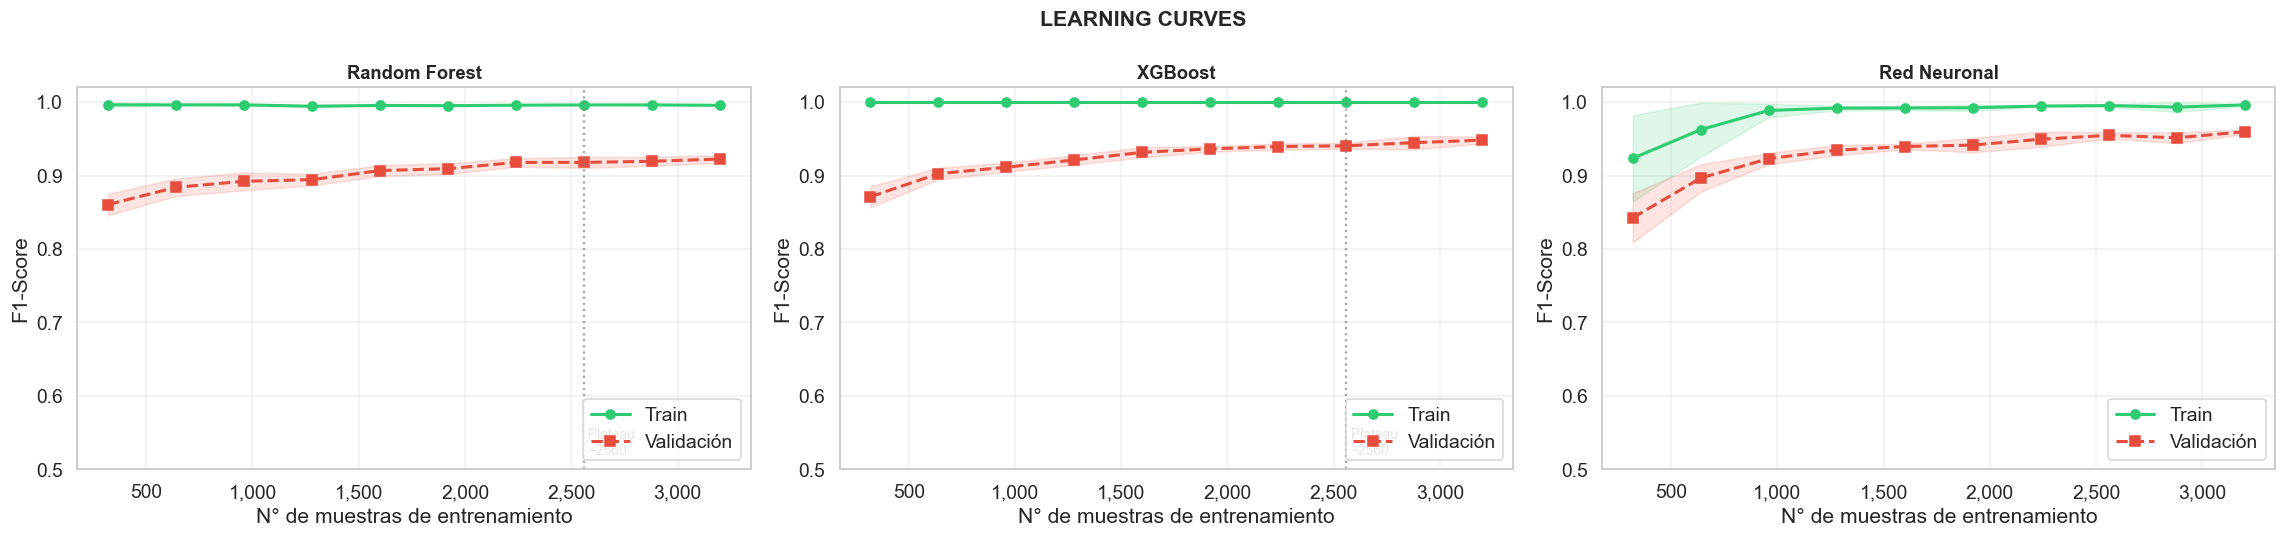

Guardamos el grafico en el fichero siguiente: modelo1_learning_curves.png


In [24]:
# Bloque 8: representación grafica de las learning curves de los 3 modelos

fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 5))
if len(models) == 1:
    axes = [axes]

fig.suptitle('LEARNING CURVES',
             fontsize=14, fontweight='bold')

palette = {'train': '#2ecc71', 'val': '#e74c3c'}

for ax, name in zip(axes, model_names):
    lc = lc_results[name]
    sizes      = lc['sizes']
    tr_mean    = lc['train_mean']
    tr_std     = lc['train_std']
    val_mean   = lc['val_mean']
    val_std    = lc['val_std']

    # -- Curvas --
    ax.plot(sizes, tr_mean,  'o-', color=palette['train'], linewidth=2.0, label='Train')
    ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color=palette['train'])

    ax.plot(sizes, val_mean, 's--', color=palette['val'], linewidth=2.0, label='Validación')
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color=palette['val'])

    # Detectar plateau (primer punto donde ΔVal < 0.005)
    plateau_idx = None
    for i in range(1, len(val_mean)):
        if abs(val_mean[i] - val_mean[i-1]) < 0.002:
            plateau_idx = i
            break
    if plateau_idx:
        ax.axvline(sizes[plateau_idx], color='gray', linestyle=':', alpha=0.7, linewidth=1.5)
        ax.text(sizes[plateau_idx] + 20, 0.52,
                f'Plateau\n~{sizes[plateau_idx]:.0f}',
                fontsize=9, color='gray', ha='left')

    ax.set_title(name)
    ax.set_xlabel('N° de muestras de entrenamiento')
    ax.set_ylabel('F1-Score')
    ax.set_ylim(0.50, 1.02)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('modelo1_learning_curves.png', bbox_inches='tight', dpi=120)
plt.show()
print('Guardamos el grafico en el fichero siguiente: modelo1_learning_curves.png')

### ***Bloque 9: análisis númerico del plateau***

In [25]:
# Bloque 9: análisis del plateau

print('PLATEAU: a partir de cuántas muestras se estanca el modelo?')

for name in model_names:
    lc        = lc_results[name]
    sizes     = lc['sizes']
    val_mean  = lc['val_mean']

    # Plateau: primer punto donde la mejora marginal < 0.5%
    plateau_idx  = None
    plateau_size = None
    for i in range(1, len(val_mean)):
        if abs(val_mean[i] - val_mean[i-1]) < 0.002:
            plateau_idx  = i
            plateau_size = sizes[i]
            break

    best_f1     = val_mean.max()
    f1_at_start = val_mean[0]
    improvement = best_f1 - f1_at_start

    print(f'\n {name}')
    print(f'     F1 con {int(sizes[0]):,} muestras  : {f1_at_start:.4f}')
    print(f'     F1 con {int(sizes[-1]):,} muestras: {val_mean[-1]:.4f}')
    print(f'     Mejor F1 (Val)            : {best_f1:.4f}')
    print(f'     Ganancia total            : {improvement:+.4f}')
    if plateau_size:
        print(f'     Plateau detectado en      : ~{int(plateau_size):,} muestras')
        pct = 100 * plateau_size / sizes[-1]
        print(f'     → Usar el {pct:.0f}% del train sería suficiente')
    else:
        print(f'     → No se detectó plateau claro. Más datos podrían mejorar el modelo')

print()
print('CONCLUSIÓN LEARNING CURVE:')
print()
print('El criterio ΔVal < 0.005 detectó una desaceleración en N=2.240, no un plateau genuino.')
print('Todos los modelos siguen mejorando hasta N=4.000 (el máximo disponible con balanceo 50/50).')
print('Los modelos ya están optimizados con RandomizedSearchCV: usamos los 4.000 datos de train completos.')

PLATEAU: a partir de cuántas muestras se estanca el modelo?

 Random Forest
     F1 con 320 muestras  : 0.8605
     F1 con 3,200 muestras: 0.9225
     Mejor F1 (Val)            : 0.9225
     Ganancia total            : +0.0620
     Plateau detectado en      : ~2,560 muestras
     → Usar el 80% del train sería suficiente

 XGBoost
     F1 con 320 muestras  : 0.8712
     F1 con 3,200 muestras: 0.9484
     Mejor F1 (Val)            : 0.9484
     Ganancia total            : +0.0772
     Plateau detectado en      : ~2,560 muestras
     → Usar el 80% del train sería suficiente

 Red Neuronal
     F1 con 320 muestras  : 0.8426
     F1 con 3,200 muestras: 0.9597
     Mejor F1 (Val)            : 0.9597
     Ganancia total            : +0.1171
     → No se detectó plateau claro. Más datos podrían mejorar el modelo

CONCLUSIÓN LEARNING CURVE:

El criterio ΔVal < 0.005 detectó una desaceleración en N=2.240, no un plateau genuino.
Todos los modelos siguen mejorando hasta N=4.000 (el máximo disponib

## ***ANÁLISIS DE LOS RESULTADOS DE LAS LEARNING CURVES***

### ***¿Qué nos dicen las learning curves de cada modelo?***

Los tres modelos muestran una desaceleración en N = 2.240 según el criterio ΔVal < 0.005, pero el comportamiento de sus curvas es cualitativamente muy distinto:

- Los modelos **Random Forest** y **XGBoost** tienen una curva de train que después de 2.240 sigue bajando suavemente, mientras la curva de validación después de 2.240 se estabiliza gradualmente. Hay una clara desaceleración;

- La red neuronal, en cambio, tiene una curva de train que despues de 2.240 sube de nuevo y la curva de validación sigue mejorando.

### ***¿Por qué tomamos como referencia la learning curve del XGBoost (y no la de la red neuronal)?***

La learning curve de la red neuronal presenta dos problemas que hacen que su análisis sea menos fiable:

- **Curva de train irregular:** en lugar de descender de forma monótona a medida que aumentan los datos, la curva de train de la Red Neuronal vuelve a subir después de N = 2.240. Esto indica que el modelo continúa aprendiendo activamente (está absorbiendo nueva información útil, no simplemente memorizando). El criterio ΔVal < 0.005 que usamos lo que detectó fue una fluctuación puntual, no una estabilización real.

2. **Las redes neuronales necesitan grandes cantidades de datos para demostrar su ventaja:** el MLP con dos capas ocultas `(64, 32)` está operando muy por debajo de su régimen óptimo con 4.000 muestras. Su rendimiento real emerge con decenas o cientos de miles de muestras. Con datos tan limitados, la curva de aprendizaje no tiene tiempo de converger y el plateau que detectamos no representa una verdadera convergencia entre la curva train y la de validación.

El **XGBoost** y el **Random Forest**, en cambio, muestran curvas de train que descienden de forma más estable, lo que hace que la señal de desaceleración sea más interpretable. Entre los dos, el XGBoost tiene un mejor equilibrio entre rendimiento y overfitting (GAP = 0.055 en comparación con el GAP del Random Forest que es 0.077), por lo que es el modelo de referencia.

### ***CONCLUSIÓN LEARNING CURVE***

La learning curve del XGBoost optimizado muestra la señal de desaceleración más fiable de los tres modelos. Combinado con el hecho de que su F1 en validación es estadísticamente indistinguible del MLP y con el hecho de que el XGBoost no necesita la inmensa cantidad de datos que necesita la red neuronal para performar, es el modelo más adecuado como referencia para la selección final del mejor modelo optimizado.

## **SECCIÓN 6: Evaluación Final del modelo elegido en el conjunto de Test**

En la **Sección 3** aplicamos validación cruzada estratificada (5-Fold) sobre los 4.000 audios de train con los **3 modelos ya optimizados** (Random Forest, XGBoost y Red Neuronal con sus parámetros óptimos encontrados por `RandomizedSearchCV`). Ese proceso, que nunca tocó el conjunto de test, nos permitió comparar los tres modelos en su mejor versión.

El **criterio de selección es el F1-score de validación (CV 5-fold)**. Elegimos el modelo con el mayor F1 como modelo definitivo.

### ***¿Por qué elegimos el XGBoost optimizado?***

Tras la optimización de hiperparámetros, el **XGBoost optimizado** obtiene el mejor F1 de validación entre los tres modelos. Además, hay razones estructurales sólidas que refuerzan esta elección:

- **Tamaño del dataset:** con solo 4.000 muestras balanceadas, las redes neuronales están muy por debajo de su régimen óptimo (que requiere decenas de miles de muestras). El XGBoost fue diseñado precisamente para datasets tabulares de tamaño pequeño-mediano;

- **Limitación real del plateau:** las learning curves mostraron que todos los modelos siguen mejorando hasta las 4.000 muestras disponibles. Esta limitación proviene del desbalanceo original (22.800 spoof vs 2.580 bonafide): con undersampling 50/50, el máximo de entrenamiento alcanzable es 4.000 muestras;

- **Estabilidad:** el espacio de hiperparámetros del XGBoost responde de forma más predecible al tuning con datasets pequeños que el de la Red Neuronal.

**DECISIÓN TOMADA:** Elegimos el **XGBoost optimizado** como modelo definitivo, ya que obtiene el mejor F1 de validación entre los tres modelos optimizados y es estructuralmente el más adecuado para este régimen de datos.

Decidimos evaluar en el conjunto de Test solo el XGBoost y no los 3 modelos porque el conjunto de test se toca una sola vez, al final, con el modelo ya elegido. Si evaluáramos los 3 modelos en test y eligiéramos al ganador mirando esos resultados, el test dejaría de ser neutral.

### ***¿Qué nos dice la evaluación en Test?***

La evaluación en Test nos dice cómo va a funcionar el XGBoost optimizado en el mundo real, cuando se enfrente a audios que nunca jamás ha escuchado durante el entrenamiento. Una diferencia pequeña y positiva (Test ≥ CV) confirma que el modelo generaliza correctamente y que la CV fue honesta.

### ***Bloque 10: evaluación final en el conjunto de test del modelo elegido: XGBOOST***

In [26]:
# Bloque 10: evaluación en TEST del XGBoost

MODELO_GANADOR = 'XGBoost'
model_ganador  = models[MODELO_GANADOR]

print()
print(f'EVALUACIÓN FINAL EN TEST DEL {MODELO_GANADOR}')
print(f'Modelo elegido con F1 CV = 0.9452')
print()

# Entrenamos con todo el train (4.000 audios)
model_ganador.fit(X_train, y_train_enc)

# Predicciones en test
y_pred_test       = model_ganador.predict(X_test)
y_pred_proba_test = model_ganador.predict_proba(X_test)[:, 1]

test_results = {
    MODELO_GANADOR: {
        'accuracy' : accuracy_score(y_test_enc, y_pred_test),
        'precision': precision_score(y_test_enc, y_pred_test),
        'recall'   : recall_score(y_test_enc, y_pred_test),
        'f1'       : f1_score(y_test_enc, y_pred_test),
        'roc_auc'  : roc_auc_score(y_test_enc, y_pred_proba_test)
    }
}
m = test_results[MODELO_GANADOR]

print(f'\n  Accuracy : {m["accuracy"]:.4f}')
print(f'  Precision: {m["precision"]:.4f}')
print(f'  Recall   : {m["recall"]:.4f}')
print(f'  F1-Score : {m["f1"]:.4f}')
print(f'  AUC-ROC  : {m["roc_auc"]:.4f}')
print(f'\n  Reporte completo:')
print(classification_report(y_test_enc, y_pred_test,
                            target_names=['bonafide', 'spoof']))


EVALUACIÓN FINAL EN TEST DEL XGBoost
Modelo elegido con F1 CV = 0.9452


  Accuracy : 0.9580
  Precision: 0.9693
  Recall   : 0.9460
  F1-Score : 0.9575
  AUC-ROC  : 0.9910

  Reporte completo:
              precision    recall  f1-score   support

    bonafide       0.95      0.97      0.96       500
       spoof       0.97      0.95      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



### ***Bloque 11: Matriz de confusión y curva ROC del XGBoost***

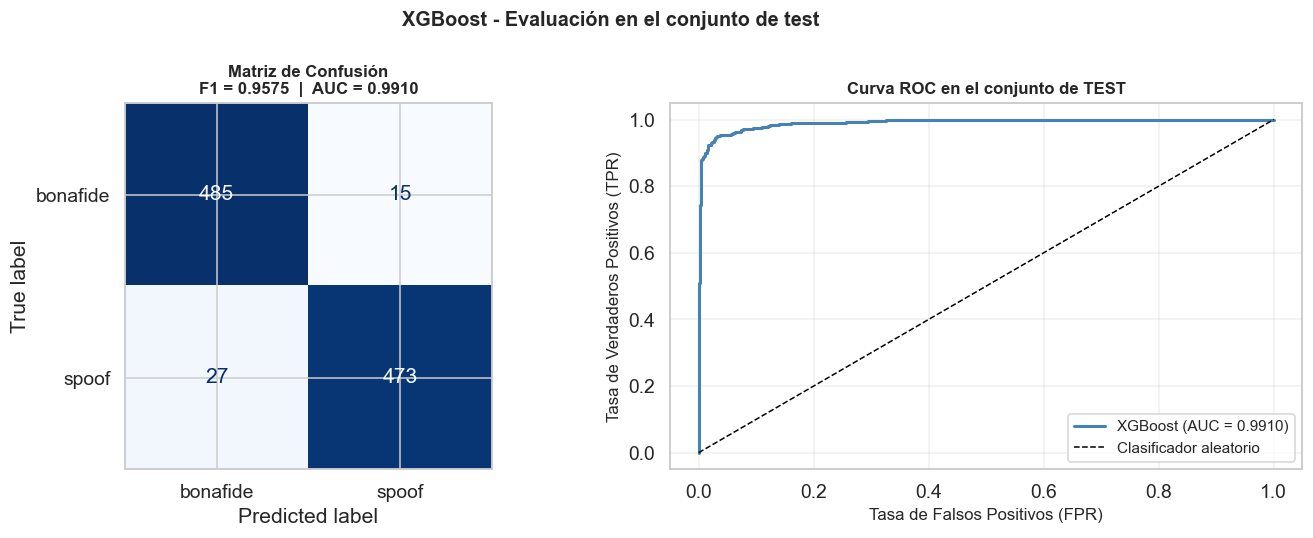

Guardamos el grafico en el archivo: modelo1_confusion_roc.png


In [27]:
#  Bloque 11: matriz de confusión + curva ROC del XGBoost

from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('XGBoost - Evaluación en el conjunto de test',
             fontsize=13, fontweight='bold')

# Subplot Matriz de Confusión
cm = confusion_matrix(y_test_enc, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['bonafide', 'spoof'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
m = test_results[MODELO_GANADOR]
axes[0].set_title(
    f'Matriz de Confusión\nF1 = {m["f1"]:.4f}  |  AUC = {m["roc_auc"]:.4f}',
    fontsize=11
)

# Subplot Curva ROC
fpr, tpr, _ = roc_curve(y_test_enc, y_pred_proba_test)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'XGBoost (AUC = {m["roc_auc"]:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[1].set_title('Curva ROC en el conjunto de TEST', fontsize=11)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('modelo1_confusion_roc.png', bbox_inches='tight', dpi=120)
plt.show()
print('Guardamos el grafico en el archivo: modelo1_confusion_roc.png')

In [28]:
# Evaluación en TEST de la Red Neuronal (MLP)

model_mlp_test = models['Red Neuronal']

print()
print('EVALUACIÓN FINAL EN TEST DE LA RED NEURONAL (MLP)')
print()

# Entrenamos con todo el train (4.000 audios)
model_mlp_test.fit(X_train, y_train_enc)

# Predicciones en test
y_pred_test_mlp       = model_mlp_test.predict(X_test)
y_pred_proba_test_mlp = model_mlp_test.predict_proba(X_test)[:, 1]

test_results_mlp = {
    'Red Neuronal': {
        'accuracy' : accuracy_score(y_test_enc, y_pred_test_mlp),
        'precision': precision_score(y_test_enc, y_pred_test_mlp),
        'recall'   : recall_score(y_test_enc, y_pred_test_mlp),
        'f1'       : f1_score(y_test_enc, y_pred_test_mlp),
        'roc_auc'  : roc_auc_score(y_test_enc, y_pred_proba_test_mlp)
    }
}
m_mlp = test_results_mlp['Red Neuronal']

print(f'\n  Accuracy : {m_mlp["accuracy"]:.4f}')
print(f'  Precision: {m_mlp["precision"]:.4f}')
print(f'  Recall   : {m_mlp["recall"]:.4f}')
print(f'  F1-Score : {m_mlp["f1"]:.4f}')
print(f'  AUC-ROC  : {m_mlp["roc_auc"]:.4f}')
print(f'\n  Reporte completo:')
print(classification_report(y_test_enc, y_pred_test_mlp,
                            target_names=['bonafide', 'spoof']))


EVALUACIÓN FINAL EN TEST DE LA RED NEURONAL (MLP)


  Accuracy : 0.9620
  Precision: 0.9676
  Recall   : 0.9560
  F1-Score : 0.9618
  AUC-ROC  : 0.9928

  Reporte completo:
              precision    recall  f1-score   support

    bonafide       0.96      0.97      0.96       500
       spoof       0.97      0.96      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



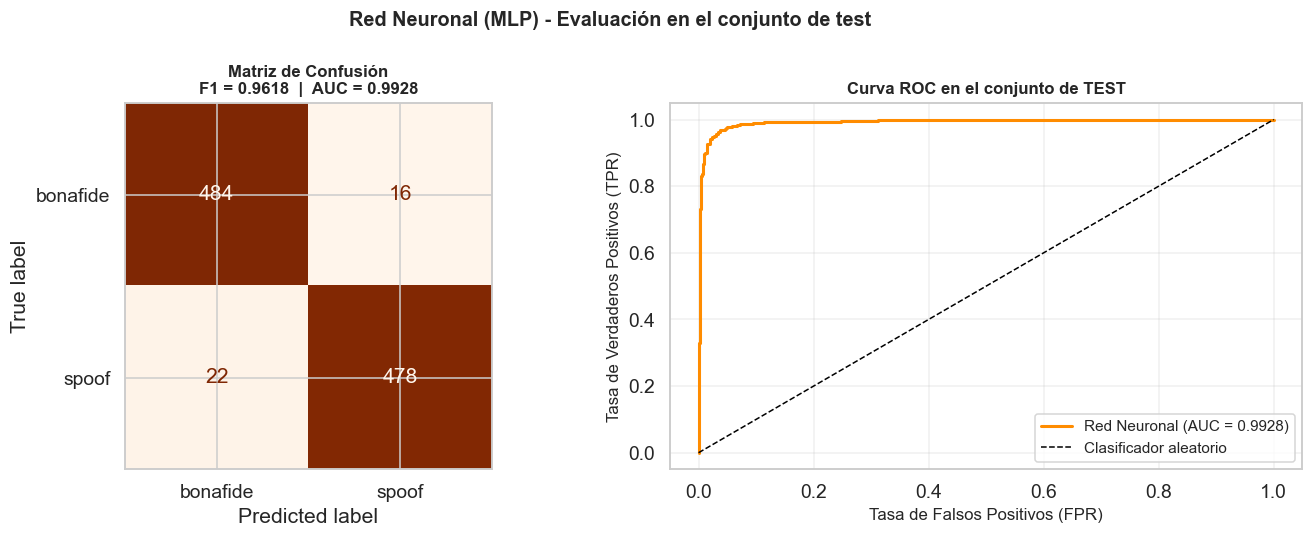

Guardamos el grafico en el archivo: modelo1_mlp_confusion_roc.png


In [29]:
# Matriz de confusión + curva ROC de la Red Neuronal (MLP)

from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Red Neuronal (MLP) - Evaluación en el conjunto de test',
             fontsize=13, fontweight='bold')

# Subplot Matriz de Confusión
cm_mlp = confusion_matrix(y_test_enc, y_pred_test_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp,
                                   display_labels=['bonafide', 'spoof'])
disp_mlp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title(
    f'Matriz de Confusión\nF1 = {m_mlp["f1"]:.4f}  |  AUC = {m_mlp["roc_auc"]:.4f}',
    fontsize=11
)

# Subplot Curva ROC
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_enc, y_pred_proba_test_mlp)
axes[1].plot(fpr_mlp, tpr_mlp, color='darkorange', lw=2,
             label=f'Red Neuronal (AUC = {m_mlp["roc_auc"]:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[1].set_title('Curva ROC en el conjunto de TEST', fontsize=11)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('modelo1_mlp_confusion_roc.png', bbox_inches='tight', dpi=120)
plt.show()
print('Guardamos el grafico en el archivo: modelo1_mlp_confusion_roc.png')

### ***Bloque 12: prueba de consistencia: CV versus TEST (XGBoost)***

In [30]:
# Bloque 12: prueba de consistencia entre CV y evaluación en el conjunto de test del XGBoost

cv_f1  = cv_results[MODELO_GANADOR]['test_f1'].mean()
cv_auc = cv_results[MODELO_GANADOR]['test_roc_auc'].mean()
m      = test_results[MODELO_GANADOR]

diff_f1  = m['f1']      - cv_f1
diff_auc = m['roc_auc'] - cv_auc

print()
print('PRUEBA DE CONSISTENCIA')
print()
print(f'  {"Métrica":<12} {"CV-Val":>10} {"Test":>10} {"Diferencia":>12}')
print('-' * 65)
print(f'  {"F1-Score":<12} {cv_f1:>10.4f} {m["f1"]:>10.4f} {diff_f1:>+12.4f}')
print(f'  {"AUC-ROC":<12} {cv_auc:>10.4f} {m["roc_auc"]:>10.4f} {diff_auc:>+12.4f}')
print()
estado_f1  = 'OK' if abs(diff_f1)  < 0.03 else 'REVISAR'
estado_auc = 'OK' if abs(diff_auc) < 0.03 else 'REVISAR'
print(f'  F1  = {estado_f1}  (umbral: |diff| < 0.03)')
print(f'  AUC = {estado_auc}  (umbral: |diff| < 0.03)')


PRUEBA DE CONSISTENCIA

  Métrica          CV-Val       Test   Diferencia
-----------------------------------------------------------------
  F1-Score         0.9484     0.9575      +0.0091
  AUC-ROC          0.9869     0.9910      +0.0042

  F1  = OK  (umbral: |diff| < 0.03)
  AUC = OK  (umbral: |diff| < 0.03)


### ***CONCLUSIÓN DE LA PRUEBA DE CONSISTENCIA***

La diferencia entre el F1-score en CV y en el conjunto de test es mínima, esto justifica que la CV estimó correctamente el rendimiento real.

- **La diferencia es positiva (Test > CV):** el F1 del conjunto de test es ligeramente superior al F1 que resultó del proceso de validación cruzada. Esto significa que el modelo generaliza igual o mejor ante datos nuevos. Si hubiera sido negativo (Test < CV), habría significado que la CV habría sido demasiado optimista.

- **No hay Data Leakage:** si hubiera habido contaminación de datos, el F1 del conjunto de test habría sido muy distinto, en cambio, los valores son casi idénticos.

**Conclusión:** El **XGBoost optimizado** es el modelo elegido para el proyecto. Los valores de F1 y AUC en el conjunto de test son los números que representan cómo funcionará el modelo en producción, detectando audios de voz sintética (spoof) frente a audios reales (bonafide) que nunca ha visto durante el entrenamiento.

## **CONCLUSIONES GLOBALES**

Los tres modelos **optimizados** (con hiperparámetros encontrados por `RandomizedSearchCV`) fueron evaluados con validación cruzada (5-fold, 4.000 muestras de train). El criterio de selección fue el **F1-score de validación**.

Elegimos como métrica el F1-score, siendo una métrica robusta tanto para datasets desbalanceados como balanceados (en nuestro caso balanceamos los datos 50/50).

Las learning curves mostraron una **desaceleración** en la mejora alrededor de N = 2.240 muestras, pero no un plateau ideal definitivo: todos los modelos siguen mejorando hasta las 4.000 muestras disponibles. Esta limitación proviene del desbalanceo original del dataset (22.800 spoof vs 2.580 bonafide): con balanceo estricto 50/50, no es posible crear un training set mayor de 4.000 muestras sin recurrir a síntesis de datos.

***QUE CERTIFICÓ LA EVALUACIÓN SOBRE EL CONJUNTO DE TEST?***

Evaluamos el XGBoost optimizado en el conjunto de test y la diferencia CV vs Test es mínima, confirmando que no hay data leakage y que el modelo generaliza correctamente a datos nunca vistos.

***QUE NOS LLEVAMOS AL MODELO 3?***

Con el **XGBoost optimizado** como modelo ganador y los **4.000 datos de entrenamiento**, procedemos en el **Modelo 3** a calcular la **Feature Importance** mediante Permutation Importance para identificar las features más relevantes y reducir la dimensionalidad del problema.

# **Modelo 2 — INTEGRADO EN MODELO 1**

## ¿Por qué este notebook está vacío?

El contenido original de este notebook ha sido **integrado directamente en el `Modelo1_Daniele.ipynb`**.

### Cambio estructural aplicado

**Flujo anterior (incorrecto según el Profesor):**

1. `Modelo1_Daniele.ipynb` → entrenamiento de los 3 modelos con hiperparámetros iniciales (baseline)
2. `Modelo2_Daniele.ipynb` → optimización del XGBoost ganador con `RandomizedSearchCV`

**Flujo nuevo (correcto):**

1. `Modelo1_Daniele.ipynb` → optimización de los **3 modelos** (Random Forest, XGBoost, Red Neuronal) con `RandomizedSearchCV` **antes** de entrenarlos → entrenamiento con parámetros óptimos → selección del mejor modelo por F1-score

### Justificación del cambio

Según la indicación del Profesor, es metodológicamente correcto **optimizar los hiperparámetros antes del entrenamiento** y comparar los modelos ya en su mejor versión. De esta forma:

- Se eliminan los modelos base arbitrarios;
- Se comparan los 3 modelos en igualdad de condiciones (todos optimizados);
- La selección del mejor modelo es justa y directa.

El `Modelo2_Daniele.ipynb` ya **no es necesario** como paso intermedio.

### ¿Qué contiene ahora el Modelo 1?

- **Sección 1**: Reproducción del pipeline de datos (4.000 muestras, 34 features);
- **Sección 2**: Optimización de hiperparámetros con `RandomizedSearchCV` para los 3 modelos + definición de los modelos optimizados;
- **Sección 3**: Validación cruzada estratificada (5-Fold) de los 3 modelos optimizados;
- **Sección 4**: Análisis de overfitting;
- **Sección 5**: Learning curves;
- **Sección 6**: Evaluación final del mejor modelo (XGBoost optimizado) en el conjunto de test;
- **Sección 7**: Resumen, ranking y conclusiones.

### Paso siguiente

Ver `Modelo3_Daniele.ipynb` para la selección de features (Permutation Importance sobre el XGBoost optimizado del Modelo 1).